In [1]:
# importa livrarias necessarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
# carrega base de dados
df = pd.read_csv("vinhos_dataset_sem_outliers.csv")

In [3]:
# Definindo os features e mostrando o cabecario e 5 linhas
features = ['citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'combined_acidity',
       'combined_sulfur_dioxide' , 'quality']
X = df[features].copy()
X.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,combined_acidity,combined_sulfur_dioxide,quality
0,0.00,1.9,0.076,0.9978,3.51,0.56,9.4,0.194643,-82.339801,5
1,0.00,2.6,0.098,0.9968,3.20,0.68,9.8,0.599492,-47.003146,5
2,0.04,2.3,0.092,0.9970,3.26,0.65,9.8,0.596156,-61.956149,5
3,0.56,1.9,0.075,0.9980,3.16,0.58,9.8,3.981499,-55.656877,6
4,0.00,1.8,0.075,0.9978,3.51,0.56,9.4,0.193531,-76.040530,5


In [4]:
# Faz o scaler dos "features" usando o standardscaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-2.18518994, -0.71051665,  0.74103634,  1.15177944,  1.78502622,
         0.21995181, -0.97685865,  0.17123861, -1.42645251, -0.91339349],
       [-2.18518994, -0.5522314 ,  1.51539249,  0.80402389, -0.16069098,
         1.0722971 , -0.63763423,  0.48851915, -0.81800489, -0.91339349],
       [-1.90912677, -0.62006794,  1.30420445,  0.873575  ,  0.21589945,
         0.85921077, -0.63763423,  0.48590478, -1.07547463, -0.91339349],
       [ 1.67969447, -0.71051665,  0.70583834,  1.22133055, -0.41175126,
         0.36200936, -0.63763423,  3.13899863, -0.96701001,  0.23019427],
       [-2.18518994, -0.73312883,  0.70583834,  1.15177944,  1.78502622,
         0.21995181, -0.97685865,  0.17036716, -1.31798789, -0.91339349]])

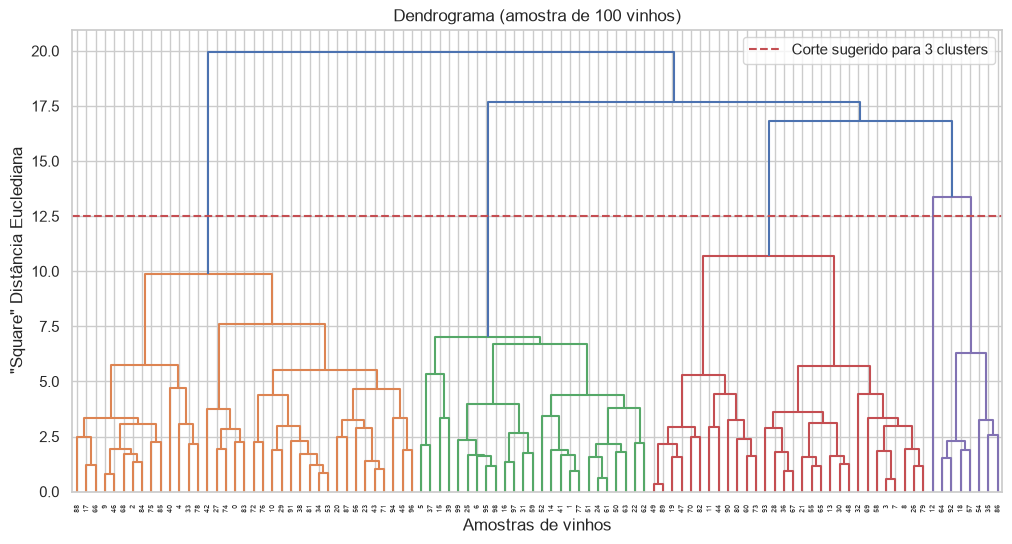

In [5]:
# Produz dendograma com uma amostra dos dados
amostra_indices = np.random.choice(len(X), size=100, replace=False)
X_amostra = X_scaled[amostra_indices]

# Calcular linkage para o dendrograma
Z = linkage(X_amostra, method='ward')

# Plotar dendrograma
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Dendrograma (amostra de 100 vinhos)')
plt.xlabel('Amostras de vinhos')
plt.ylabel('"Square" Distância Euclediana')
plt.axhline(y=12.5, color='r', linestyle='--', label='Corte sugerido para 3 clusters')
plt.legend()
plt.show()

In [6]:
# Execucao do modelo HAC
n_clusters_escolhido = 2

linkage_method = 'average'
hac = AgglomerativeClustering(n_clusters=n_clusters_escolhido, linkage=linkage_method)
clusters = hac.fit_predict(X_scaled)
clusters[:20]

hac = AgglomerativeClustering(n_clusters=n_clusters_escolhido, linkage=linkage_method)
clusters_treino = hac.fit_predict(X_scaled)
clusters_treino[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [7]:
#Adicionando os clusters ao DataFrame principal
df['cluster'] = clusters_treino
df.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide,cluster
0,0.00,1.9,0.076,0.9978,3.51,0.56,9.4,5,0,0.194643,-82.339801,0
1,0.00,2.6,0.098,0.9968,3.20,0.68,9.8,5,0,0.599492,-47.003146,0
2,0.04,2.3,0.092,0.9970,3.26,0.65,9.8,5,0,0.596156,-61.956149,0
3,0.56,1.9,0.075,0.9980,3.16,0.58,9.8,6,0,3.981499,-55.656877,0
4,0.00,1.8,0.075,0.9978,3.51,0.56,9.4,5,0,0.193531,-76.040530,0


In [8]:
# Calcula as estatísticas agrupadas por cluster
resumo = df.groupby('cluster')[features].agg(['mean', 'std', 'min', 'max'])

# Transpõe a tabela (Gira os clusters para as colunas e variáveis para as linhas)
resumo_transposto = resumo.T

# Organiza o índice duplo para virar duas colunas normais ("Variável" e "Métrica")
resumo_transposto = resumo_transposto.reset_index()
resumo_transposto.rename(columns={'level_0': 'Variável', 'level_1': 'Métrica'}, inplace=True)

# Envia o resultado final para a área de transferência
resumo_transposto.to_clipboard(excel=True, index=True)



In [9]:
# Quantos vinhos em cada cluster
df['cluster'].value_counts().sort_index()

cluster
0    5265
1       1
Name: count, dtype: int64

In [10]:
# Resumo dos clusters
clusters_validos = sorted(df['cluster'].unique())
n_clusters_encontrados = len(clusters_validos)
n_pontos_total = len(df)

print('Número de clusters encontrados:', n_clusters_encontrados)
print('Total de pontos:', n_pontos_total)

Número de clusters encontrados: 2
Total de pontos: 5266


In [11]:
# Avaliação rápida com silhouette score

mask_todos = df['cluster'] >= 0
X_todos = X_scaled[mask_todos]
labels_todos = df.loc[mask_todos, 'cluster']

if len(set(labels_todos)) >= 2:
    sil = silhouette_score(X_todos, labels_todos)
    print('Silhouette Score:', round(sil, 4))
else:
    print('Silhouette Score não pode ser calculado: menos de 2 clusters válidos.')

Silhouette Score: 0.619


In [12]:
# Redução dos dados para 2 dimensões usando PCA

from sklearn.decomposition import PCA

# Cria o modelo PCA para reduzir para 2 componentes
pca = PCA(n_components=2)

# Aplica o PCA aos dados padronizados
X_pca = pca.fit_transform(X_scaled)

# Mostra a variância explicada por cada componente
print("Variância explicada pelo PCA 1:", round(pca.explained_variance_ratio_[0], 4))
print("Variância explicada pelo PCA 2:", round(pca.explained_variance_ratio_[1], 4))
print("Variância explicada acumulada:", round(pca.explained_variance_ratio_.sum(), 4))

Variância explicada pelo PCA 1: 0.2618
Variância explicada pelo PCA 2: 0.2211
Variância explicada acumulada: 0.4829


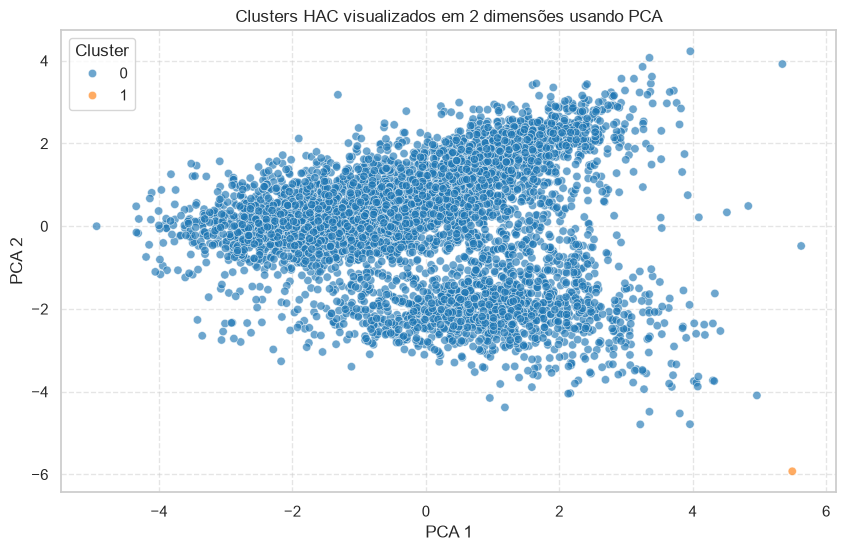

In [13]:
# Visualização dos clusters utilizando PCA

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Gráfico PCA 1 x PCA 2, colorido pelos clusters do HAC

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='tab10',
    alpha=0.65
)

plt.title('Clusters HAC visualizados em 2 dimensões usando PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [14]:
# Obtém os pesos (loadings) das variáveis em PCA1 e PCA2

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=features
)

print(loadings)

                             PCA1      PCA2
citric_acid              0.110418  0.166584
residual_sugar           0.252192  0.465720
chlorides                0.344219 -0.339831
density                  0.570892 -0.013042
pH                      -0.093460 -0.298574
sulphates                0.160031 -0.392282
alcohol                 -0.484590 -0.155916
combined_acidity         0.324287 -0.261161
combined_sulfur_dioxide  0.040419  0.550568
quality                 -0.322234 -0.032064


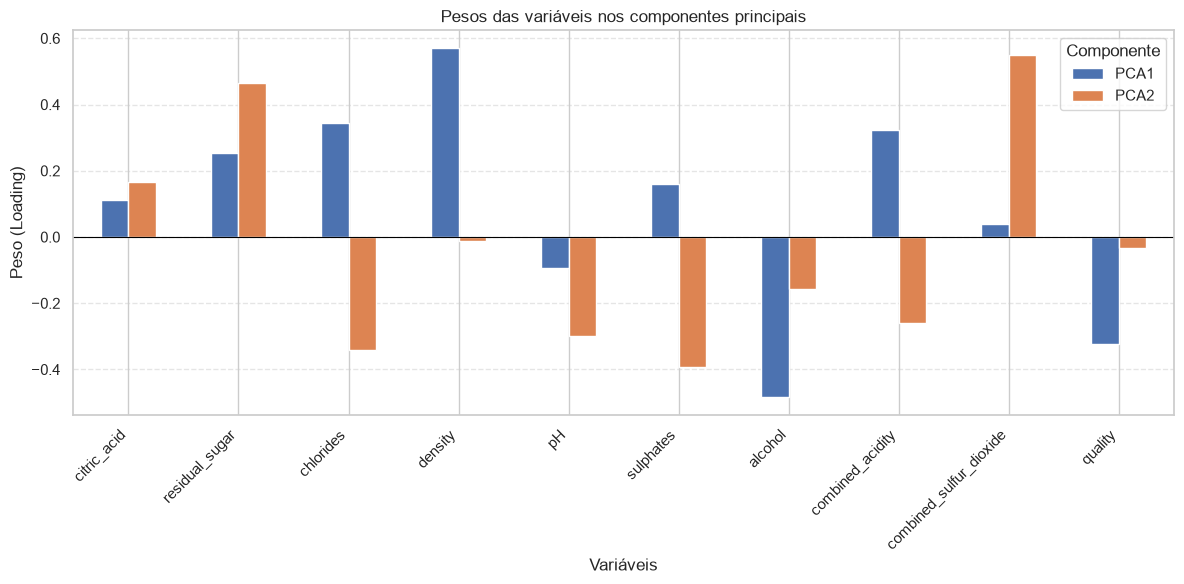

In [15]:
# Gráfico dos pesos das variáveis em PCA1 e PCA2

loadings.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Pesos das variáveis nos componentes principais')
plt.xlabel('Variáveis')
plt.ylabel('Peso (Loading)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Componente')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Calculando Silhouette Scores para todas as variações de linkage...
Linkage 'ward': Melhor Score foi 0.2284 com k = 2
Linkage 'complete': Melhor Score foi 0.5006 com k = 2
Linkage 'average': Melhor Score foi 0.6190 com k = 2
Linkage 'single': Melhor Score foi 0.5728 com k = 2


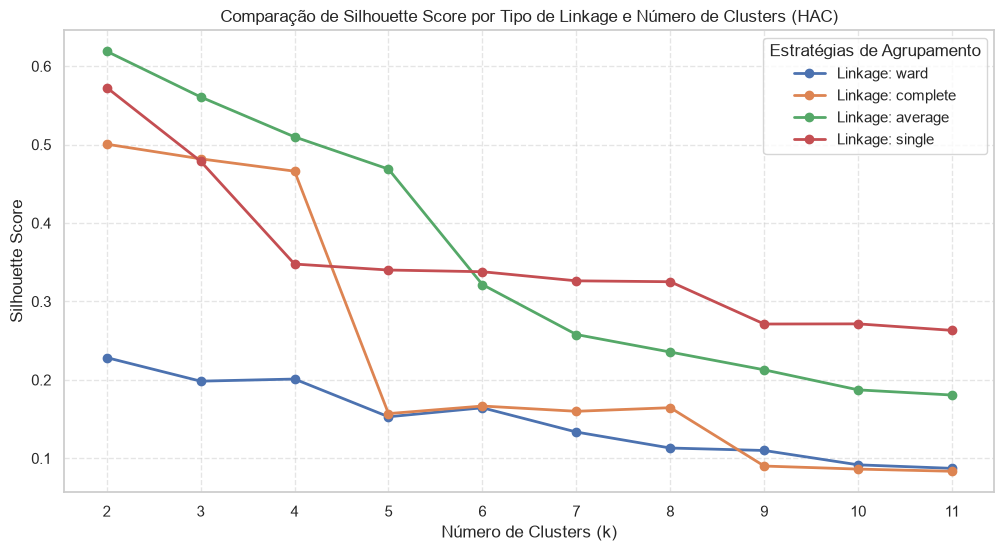

In [16]:
# Definindo as 4 variações de linkage suportadas pelo HAC
variacoes_linkage = ['ward', 'complete', 'average', 'single']

# Definindo o intervalo para 10 diferentes valores de k (de 2 a 12)
valores_k = range(2, 12)

# Criando a figura do gráfico para plotar todas as linhas juntas
plt.figure(figsize=(12, 6))

print("Calculando Silhouette Scores para todas as variações de linkage...")

# Loop principal: passa por cada tipo de linkage
for metodo_linkage in variacoes_linkage:
    scores_do_metodo = []
    
    # Loop secundário: passa por cada número de clusters (k)
    for k in valores_k:
        # Configura e treina o modelo HAC com o linkage e k atuais
        hac_teste = AgglomerativeClustering(n_clusters=k, linkage=metodo_linkage)
        labels_teste = hac_teste.fit_predict(X_scaled)
        
        # Calcula o silhouette score para esta combinação
        score = silhouette_score(X_scaled, labels_teste)
        scores_do_metodo.append(score)
        
    # Exibe no terminal o melhor resultado encontrado para este método específico
    maior_score = max(scores_do_metodo)
    k_ideal = valores_k[scores_do_metodo.index(maior_score)]
    print(f"Linkage '{metodo_linkage}': Melhor Score foi {maior_score:.4f} com k = {k_ideal}")
    
    # Plota a linha deste método de linkage no gráfico geral
    plt.plot(valores_k, scores_do_metodo, marker='o', linestyle='-', label=f'Linkage: {metodo_linkage}', linewidth=2)

# Customização e finalização do gráfico comparativo
plt.title('Comparação de Silhouette Score por Tipo de Linkage e Número de Clusters (HAC)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Estratégias de Agrupamento')
plt.show()